# Mini Project 8 :- Customer Segmentation Using K-Means Clustering

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
# customer id imp column nhi h yha... isko drop kr denge...
df.drop("CustomerID", axis=1, inplace=True)

In [11]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [12]:
df["Gender"] = df["Gender"].map({"Male":0,"Female":1})    # mapping

In [13]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


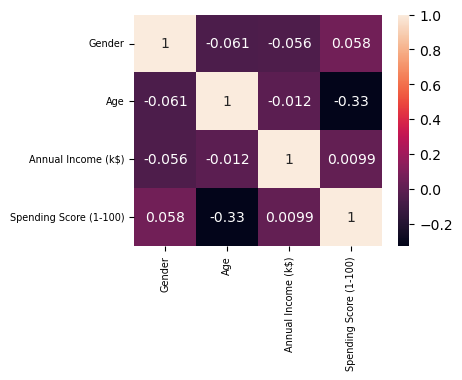

In [14]:
# heatmap 
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(), annot=True)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

# K-Means-Clustering :-

In [ ]:
# K-Means Clustering ek unsupervised machine learning algorithm hai jo data ko groups (clusters) me divide karta hai based on similarity.

# “Ye algorithm similar data points ko ek group me aur different ones ko alag groups me divide karta hai.”

# why K-Means :- K = number of clusters.....Means = average (centroid of cluster)

# Har cluster ka ek center hota hai (mean of points)

In [15]:
# feature selection :-
# Income aur Spending behavior ke basis par customers ko group kiya h
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [16]:
# Scaling :-

from sklearn.preprocessing import StandardScaler

# Income aur Spending alag scales par ho sakte hain.
# Scaling se dono features equal importance paate hain.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Mthod :-

In [18]:
from sklearn.cluster import KMeans

C:\Users\cxash\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cxash\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cxash\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cxash\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

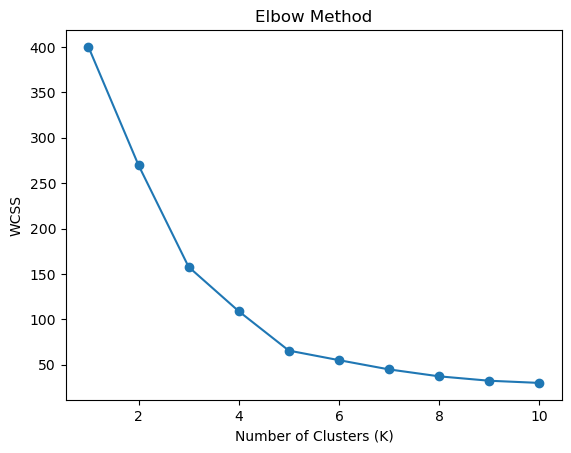

In [19]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)   # inertia = WCSS

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# Best K choose karne ke liye....Jaha graph elbow bana raha ho, wo optimal cluster count hota hai.

In [20]:
wcss

[399.99999999999994,
 269.69101219276394,
 157.70400815035947,
 108.92131661364357,
 65.56840815571681,
 55.057348270386,
 44.86475569922557,
 37.228187677585886,
 32.39226763033116,
 29.981897788243696]

# K-Means Model :-

In [21]:
model = KMeans(n_clusters=5, random_state=42, n_init=10 )

# Customers ko clusters me assign karne ke liye.

In [22]:
clusters = model.fit_predict(X_scaled)

C:\Users\cxash\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
df["cluster"] = clusters   # Har customer kis cluster me hai store karne ke liye.

In [24]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4


In [25]:
df["cluster"].value_counts()

cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

# Visualize Clusters :-

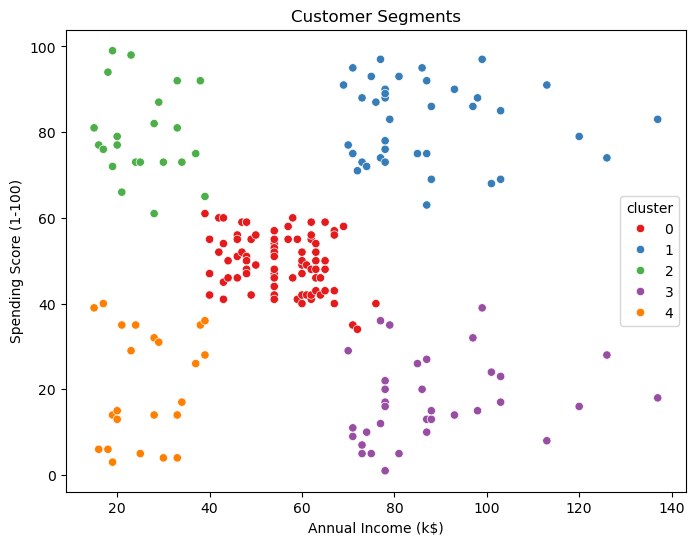

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
plt.title("Customer Segments")
plt.show()

In [27]:
centeroid = scaler.inverse_transform(model.cluster_centers_)

In [28]:
centeroid

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])